# generate_ancillary 模块演示与验证

本 Notebook 做两件事：

1. **演示怎么用**：读取已预处理的样例数据，调用迁移后算法，看看输入/输出长什么样。
2. **验证算得对不对**：把迁移后的结果与原 IMPROVER 方法、官方样例结果（KGO）做数值对比。

覆盖算法分别是：

- `CorrectLandSeaMask`：把插值后的海陆分数（`land_fraction`，0 到 1 的小数）按 0.5 切开，变成海 0 / 陆 1 的二值掩码。
- `GenerateOrographyBandAncils`：按高度阈值把地形分成若干带，每带输出一张 0/1 掩码（格点落在该带内为 1）。可选再乘上海陆掩码，只保留陆地。
- `GenerateTopographicZoneWeights`：按高度在各地形带内的位置生成折叠权重（带中点=1、边界=0.5，剩余权重分给相邻带）。可选屏蔽海点。

官方样例是**投影网格**的（KGO 也是投影网格）。因此本模块先做**投影路径完整验证**；
后面的经纬路径是把同一套投影场重网格到经纬，用来确认：算法换成 meb 六维之后，在真经纬坐标上仍能和原方法对上。

请先在仓库根目录运行一次预处理（只需做一次，会写出 `cli_inputs/` 和 `latlon/`）：

```text
python generate_ancillary/cli/preprocess_test_data.py
```


## 1. 环境准备

下面几行只做三件事：找到本模块目录、让 Python 能 import 本仓库代码、打开中文绘图。


In [1]:
%matplotlib inline

from pathlib import Path
import json
import sys
import warnings

import iris
import meteva_base as meb
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import xarray as xr

# 屏蔽第三方库的过时提示，避免干扰阅读输出
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="pkg_resources is deprecated")

# 图里的中文、负号能正常显示
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "SimSun", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (15, 4.5)

# 本 Notebook 一般从 generate_ancillary/nbs/ 打开：
#   上一级 = 本模块目录
#   再上一级 = 仓库根目录
PACKAGE_ROOT = Path.cwd().resolve().parents[0]
PROJECT_ROOT = PACKAGE_ROOT.parent
IMPROVER_ROOT = PROJECT_ROOT / "improver-1.18.7"

for path in (str(PROJECT_ROOT), str(IMPROVER_ROOT)):
    if path not in sys.path:
        sys.path.insert(0, path)

# 迁移后方法（读 meb 六维）
from generate_ancillary.src.generate_ancillary import (
    THRESHOLDS_DICT,
    CorrectLandSeaMask,
    GenerateOrographyBandAncils,
)
from generate_ancillary.src.generate_topographic_zone_weights import (
    GenerateTopographicZoneWeights,
)

# 原 IMPROVER 方法（读 Iris Cube），用来对照
from improver.generate_ancillaries.generate_ancillary import (  # pyright: ignore[reportMissingImports]
    CorrectLandSeaMask as OrigCorrectLandSeaMask,
    GenerateOrographyBandAncils as OrigBandsPlugin,
)
from improver.generate_ancillaries.generate_topographic_zone_weights import (  # pyright: ignore[reportMissingImports]
    GenerateTopographicZoneWeights as OrigWeightsPlugin,
)

# 海陆掩码、地形带掩码、地形带权重各用一套官方样例目录
LANDMASK_ROOT = PACKAGE_ROOT / "test_data" / "generate-landmask"
LANDMASK_BASIC = LANDMASK_ROOT / "basic"
BANDS_ROOT = PACKAGE_ROOT / "test_data" / "generate-topography-bands-mask"
BASIC_DIR = BANDS_ROOT / "basic"
NO_LANDMASK_DIR = BANDS_ROOT / "basic_no_landsea_mask"
WEIGHTS_ROOT = PACKAGE_ROOT / "test_data" / "generate-topography-bands-weights"
WEIGHTS_BASIC = WEIGHTS_ROOT / "basic"
WEIGHTS_NO_LANDMASK = WEIGHTS_ROOT / "basic_no_landsea_mask"
WEIGHTS_MULTI = WEIGHTS_ROOT / "multi_realization"

LM_CLI_INPUT = LANDMASK_BASIC / "cli_inputs"
LM_CLI_OUTPUT = LANDMASK_BASIC / "cli_outputs"
CLI_INPUT_DIR = BASIC_DIR / "cli_inputs"
CLI_OUTPUT_DIR = BASIC_DIR / "cli_outputs"
W_CLI_INPUT = WEIGHTS_BASIC / "cli_inputs"
W_CLI_OUTPUT = WEIGHTS_BASIC / "cli_outputs"

print("模块目录:", PACKAGE_ROOT)
print("海陆掩码样例:", LANDMASK_BASIC)
print("地形带掩码样例:", BASIC_DIR)
print("地形带权重样例:", WEIGHTS_BASIC)


d:\workspace\improver\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


模块目录: D:\workspace\improver\generate_ancillary
海陆掩码样例: D:\workspace\improver\generate_ancillary\test_data\generate-landmask\basic
地形带掩码样例: D:\workspace\improver\generate_ancillary\test_data\generate-topography-bands-mask\basic
地形带权重样例: D:\workspace\improver\generate_ancillary\test_data\generate-topography-bands-weights\basic


## 2. 读数、对比、画图用的小工具

后面每组输入都会反复做三件事：读文件、比两个场差多少、画并排图。
先把这些步骤写成函数，正文里就只剩“读哪些文件、调用哪个算法”。


In [2]:
def require_files(paths, label: str) -> None:
    """缺文件时给出明确提示，避免后面读盘才报一长串错误。"""
    missing = [str(p) for p in paths if not Path(p).exists()]
    if missing:
        raise FileNotFoundError(
            f"缺少{label}（共 {len(missing)} 个）。"
            "请先运行: python generate_ancillary/cli/preprocess_test_data.py\n"
            + "\n".join(missing[:8])
        )


def to_2d(data) -> np.ndarray:
    """把六维场或 Cube 压成一张二维图，方便比数值、画图。"""
    arr = np.asarray(data.values if hasattr(data, "values") else data.data, dtype=np.float64)
    return np.squeeze(arr)


def first_band_2d(data) -> np.ndarray:
    """取出第 0 个地形带，压成二维。meb 用 level，Iris Cube 用第 0 维 topographic_zone。"""
    if isinstance(data, xr.DataArray):
        return to_2d(data.isel(level=0))
    return np.asarray(data.data[0], dtype=np.float64)


def print_max_abs(left, right, tag: str) -> None:
    """打印最大绝对误差。接近 0 表示两边几乎一样。"""
    diff = np.asarray(left, dtype=np.float64) - np.asarray(right, dtype=np.float64)
    print(f"[{tag}] 最大绝对误差={np.nanmax(np.abs(diff)):.8f}（接近 0 表示一致）")


def common_limits(*arrays) -> tuple[float, float]:
    """为多张结果图生成统一色标范围，方便直接看是否长得像。"""
    stacked = [np.asarray(item, dtype=np.float32) for item in arrays]
    return float(np.nanmin(stacked)), float(np.nanmax(stacked))


def describe_bands(bands_config: dict) -> str:
    """以表格格式返回每个地形带的中心高度与上下界"""
    bounds = bands_config["bounds"]
    
    lines = ["band_index | center | lower | upper"]
    for idx, (lower, upper) in enumerate(bounds):
        center = (lower + upper) / 2.0
        lines.append(f"{idx:>10d} | {center:>6.1f} | {lower:>6.1f} | {upper:>6.1f}")
    
    return "\n".join(lines)

def plot_auxiliary_data(title: str, orography: xr.DataArray, landmask: xr.DataArray | None = None) -> None:
    """绘制输入地形；若给了海陆掩码，右侧再画一张。"""
    ncols = 2 if landmask is not None else 1
    fig, axes = plt.subplots(1, ncols, figsize=(6.2 * ncols, 4.8), constrained_layout=True)
    if ncols == 1:
        axes = [axes]

    image = axes[0].imshow(
        to_2d(orography),
        cmap="terrain",
        interpolation="nearest",
        origin="lower",
    )
    axes[0].set_title(f"{title}: 地形高度")
    plt.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04)

    if landmask is not None:
        cmap = ListedColormap(["lightblue", "darkseagreen"])
        mask_image = axes[1].imshow(
            to_2d(landmask),
            cmap=cmap,
            vmin=0,
            vmax=1,
            interpolation="nearest",
            origin="lower",
        )
        axes[1].set_title(f"{title}: 海陆掩码")
        cbar = plt.colorbar(mask_image, ax=axes[1], fraction=0.046, pad=0.04, ticks=[0, 1])
        cbar.ax.set_yticklabels(["海 (0)", "陆 (1)"])

    plt.show()


def plot_result_triplet(title: str, modified: np.ndarray, kgo: np.ndarray, original: np.ndarray) -> None:
    """三列对比：修改后方法 | KGO | 原方法，共用色标。"""
    vmin, vmax = common_limits(modified, kgo, original)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
    panels = [
        ("修改后方法", modified),
        ("预期结果", kgo),
        ("原方法", original),
    ]
    for ax, (panel_title, values) in zip(axes, panels):
        image = ax.imshow(
            values,
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest",
            origin="lower",
        )
        ax.set_title(panel_title)
        plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title)
    plt.show()


def plot_landmask_pair_or_triplet(title: str, current, original, kgo=None) -> None:
    """海陆掩码对比图；有 KGO 时画三列，否则只画修改后方法 vs 原方法。"""
    arrays = [to_2d(current), to_2d(original)]
    labels = ["修改后方法", "原方法"]
    if kgo is not None:
        arrays.append(to_2d(kgo))
        labels.append("KGO")
    ncols = len(arrays)
    fig, axes = plt.subplots(1, ncols, figsize=(5.5 * ncols, 4.5), constrained_layout=True)
    if ncols == 1:
        axes = [axes]
    cmap = ListedColormap(["lightblue", "darkseagreen"])
    for ax, values, label in zip(axes, arrays, labels):
        image = ax.imshow(
            values,
            cmap=cmap,
            vmin=0,
            vmax=1,
            interpolation="nearest",
            origin="lower",
        )
        ax.set_title(label)
        cbar = plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04, ticks=[0, 1])
        cbar.ax.set_yticklabels(["海 (0)", "陆 (1)"])
    fig.suptitle(title)
    plt.show()


def plot_pair(title: str, current, original) -> None:
    """两列对比（经纬路径没有投影 KGO，只比修改后方法与原方法）。"""
    a = to_2d(current)
    b = to_2d(original)
    vmin, vmax = common_limits(a, b)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
    for ax, arr, label in zip(axes, (a, b), ("修改后方法", "原方法")):
        im = ax.imshow(arr, cmap="viridis", vmin=vmin, vmax=vmax, interpolation="nearest", origin="lower")
        ax.set_title(label)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title)
    plt.show()




def weights_band_stack(data) -> np.ndarray:
    """权重场压成 (n_band, y, x)；海点统一为 NaN（含 Iris 1e20 填充）。"""
    if isinstance(data, xr.DataArray):
        arr = np.asarray(data.values, dtype=np.float64)
        while arr.ndim > 3:
            if arr.shape[0] == 1:
                arr = arr[0]
            else:
                arr = np.squeeze(arr)
                break
        if arr.ndim != 3:
            raise ValueError(f"权重 DataArray 期望 3 维 (band,y,x)，实际 shape={arr.shape}")
    else:
        raw = data.data if hasattr(data, "data") else data
        if np.ma.isMaskedArray(raw):
            arr = np.ma.filled(np.asarray(raw, dtype=np.float64), np.nan)
        else:
            arr = np.asarray(raw, dtype=np.float64)
    arr = np.asarray(arr, dtype=np.float64).copy()
    arr[~np.isfinite(arr)] = np.nan
    arr[np.abs(arr) >= 1.0e20] = np.nan
    return arr


def ensure_single_member(da: xr.DataArray) -> xr.DataArray:
    """权重插件要求 member 长度为 1；多成员样例取第 0 个并保留维。"""
    if "member" in da.dims and da.sizes["member"] > 1:
        return da.isel(member=[0])  # 保留 member 维，长度为 1
    return da

print("工具函数已就绪。")


工具函数已就绪。


## 3. 投影坐标输入

这里读的是 `cli_inputs/`：投影坐标只是把维名改成了 `lat`/`lon`，**数值仍是米制投影**。
迁移方法用 `meb.read_griddata_from_nc` 读六维网格；KGO 和原方法结果是官方 Iris 格式，用 `iris.load_cube` 读。


### 3.1 CorrectLandSeaMask

官方样例：`test_data/generate-landmask/basic`。
输入是插值后的浮点 `land_fraction`（0–1）；输出是二值 `land_binary_mask`（海 0 / 陆 1）。


#### 输入数据绘图

看一眼插值后的海陆比例：越接近 1 越像陆地，越接近 0 越像海洋。算法会把小于 0.5 的格点打成海。


In [3]:
land_meb_path = LM_CLI_INPUT / "input_landmask_meb.nc"
require_files([land_meb_path], "海陆掩码输入")

# 迁移方法读 meb 六维；KGO / 原方法读官方 Cube
land_frac = meb.read_griddata_from_nc(str(land_meb_path))
kgo_landmask = iris.load_cube(str(LANDMASK_BASIC / "kgo.nc"))
print("input:", land_frac.name, land_frac.shape, "units=", land_frac.attrs.get("units"))

input: land_fraction (1, 1, 1, 1, 49, 53) units= 1


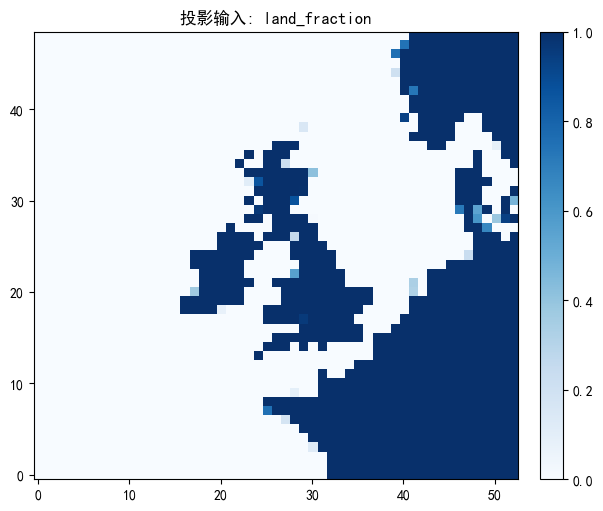

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(6.5, 5), constrained_layout=True)
im = ax.imshow(
    to_2d(land_frac),
    cmap="Blues",
    vmin=0,
    vmax=1,
    origin="lower",
    interpolation="nearest",
)
ax.set_title("投影输入: land_fraction")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()


#### 算法运行与数值对比

先创建算法对象，再传入海陆比例场。三个结果（迁移方法、原方法、KGO）应完全一致。


In [5]:
# 按 0.5 阈值把小数比例变成 0/1
cur_landmask = CorrectLandSeaMask().process(land_frac)

land_cube = iris.load_cube(str(LANDMASK_BASIC / "input.nc"))
orig_landmask_cube = OrigCorrectLandSeaMask()(land_cube)

cur_2d = to_2d(cur_landmask).astype(np.float64)
kgo_2d = to_2d(kgo_landmask).astype(np.float64)
orig_2d = to_2d(orig_landmask_cube).astype(np.float64)
print_max_abs(cur_2d, kgo_2d, "修改后方法 vs KGO")
print_max_abs(cur_2d, orig_2d, "修改后方法 vs 原方法")
np.testing.assert_array_equal(cur_2d, kgo_2d)
np.testing.assert_array_equal(cur_2d, orig_2d)
print("CorrectLandSeaMask 投影路径：与 KGO、原方法一致。")


[修改后方法 vs KGO] 最大绝对误差=0.00000000（接近 0 表示一致）
[修改后方法 vs 原方法] 最大绝对误差=0.00000000（接近 0 表示一致）
CorrectLandSeaMask 投影路径：与 KGO、原方法一致。


#### 输出对比绘图

三列应看起来一样：浅蓝是海，绿色是陆。


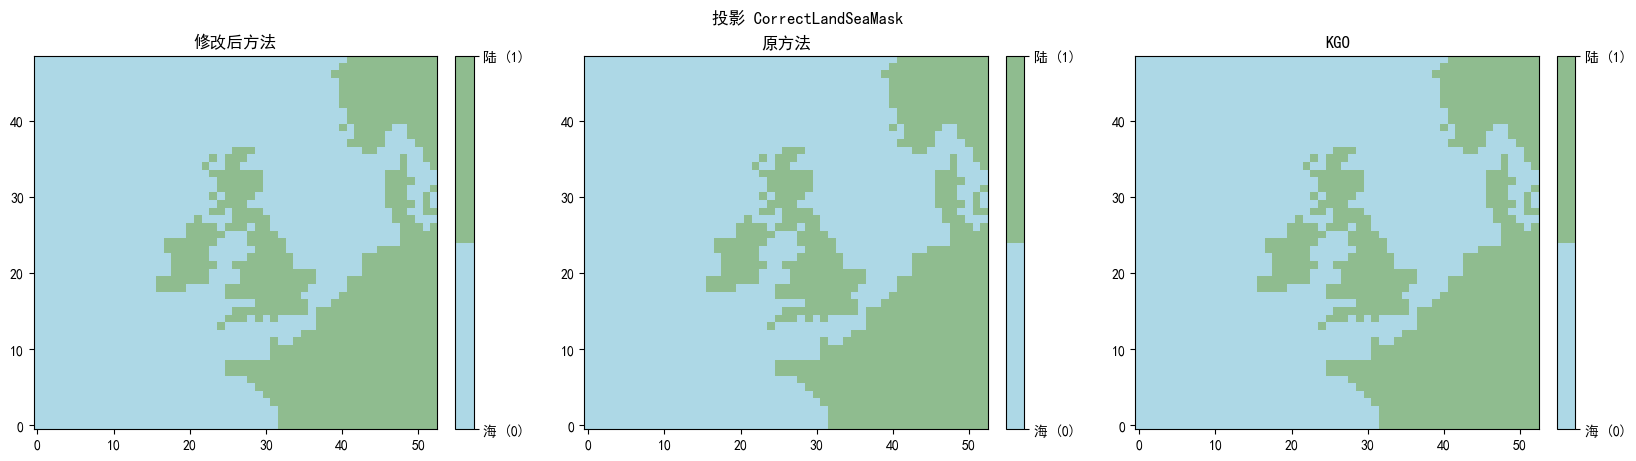

In [6]:
plot_landmask_pair_or_triplet(
    "投影 CorrectLandSeaMask",
    cur_2d,
    orig_2d,
    kgo=kgo_2d,
)


### 3.2 GenerateOrographyBandAncils

官方样例：`test_data/generate-topography-bands-mask`。

下面跑三种常见用法：默认阈值 + 海陆掩码、JSON 自定义阈值、以及不传海陆掩码（陆地和海洋都分带）。


#### 输入数据绘图

左侧是地形高度，右侧是已经二值化的海陆掩码（这张掩码会限制“只在陆地上分带”）。


In [7]:
orog_meb_path = CLI_INPUT_DIR / "input_orog_meb.nc"
land_meb_path = CLI_INPUT_DIR / "input_land_meb.nc"
require_files([orog_meb_path, land_meb_path], "地形带投影 meb")
orography = meb.read_griddata_from_nc(str(orog_meb_path))
landmask = meb.read_griddata_from_nc(str(land_meb_path))

# 读取 JSON 格式的地形带上下界
with open(BASIC_DIR / "bounds.json", "r", encoding="utf-8") as infile:
    json_thresholds = json.load(infile)

print("orography:", orography.name, orography.shape)
print("landmask:", landmask.name, landmask.shape)
print("="*11," 默认阈值 ","="*11)
print(describe_bands(THRESHOLDS_DICT))
print("="*11," JSON 阈值 ","="*11)
print(describe_bands(json_thresholds))

orography: surface_altitude (1, 1, 1, 1, 100, 100)
landmask: land_binary_mask (1, 1, 1, 1, 100, 100)
===========  默认阈值  ===========
band_index | center | lower | upper
         0 | -225.0 | -500.0 |   50.0
         1 |   75.0 |   50.0 |  100.0
         2 |  125.0 |  100.0 |  150.0
         3 |  175.0 |  150.0 |  200.0
         4 |  225.0 |  200.0 |  250.0
         5 |  275.0 |  250.0 |  300.0
         6 |  350.0 |  300.0 |  400.0
         7 |  450.0 |  400.0 |  500.0
         8 |  575.0 |  500.0 |  650.0
         9 |  725.0 |  650.0 |  800.0
        10 |  875.0 |  800.0 |  950.0
        11 | 3475.0 |  950.0 | 6000.0
===========  JSON 阈值  ===========
band_index | center | lower | upper
         0 | -250.0 | -500.0 |    0.0
         1 |   75.0 |    0.0 |  150.0
         2 |  175.0 |  150.0 |  200.0
         3 |  250.0 |  200.0 |  300.0
         4 |  450.0 |  300.0 |  600.0


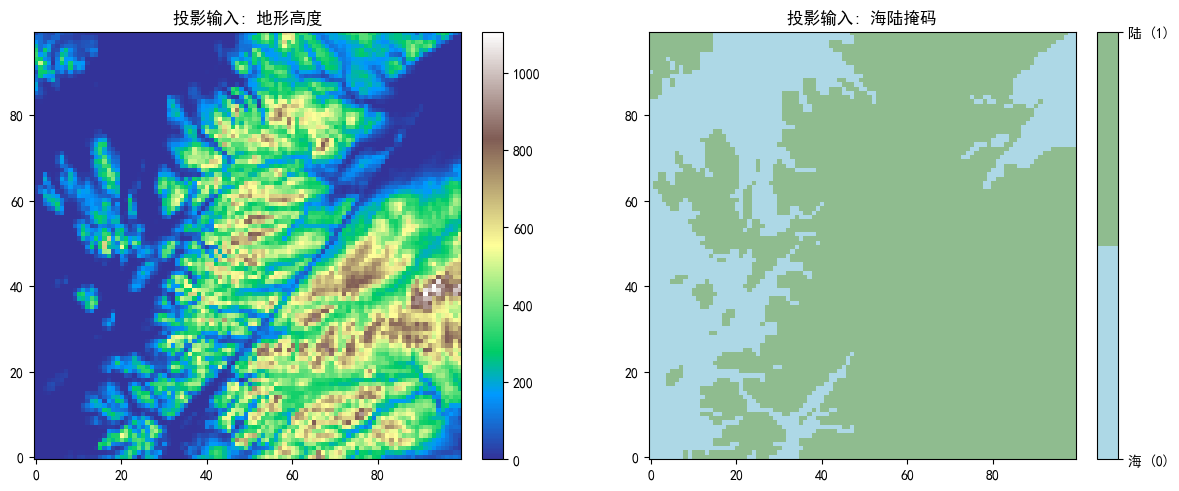

In [8]:
plot_auxiliary_data(
    "投影输入",
    orography.isel(member=0, level=0, time=0, dtime=0),
    landmask.isel(member=0, level=0, time=0, dtime=0),
)


#### 算法运行与数值对比

`THRESHOLDS_DICT` 是模块内置的默认分带；`bounds.json` 是官方样例里的另一套上下界。


In [9]:
# 迁移方法：同一套地形，三种分带方式
plugin = GenerateOrographyBandAncils()
result_basic = plugin(orography, THRESHOLDS_DICT, landmask=landmask)
result_json = plugin(orography, json_thresholds, landmask=landmask)
result_no_landmask = plugin(orography, THRESHOLDS_DICT, landmask=None)

# 原方法现场调用（Iris Cube）；concatenate_cube 把各带拼成一个 Cube
orog_cube = iris.load_cube(str(BASIC_DIR / "input_orog.nc"))
land_cube = iris.load_cube(str(BASIC_DIR / "input_land.nc"))
orig_plugin = OrigBandsPlugin()
original_basic = orig_plugin(
    orog_cube.copy(), THRESHOLDS_DICT, landmask=land_cube.copy()
).concatenate_cube()
original_json = orig_plugin(
    orog_cube.copy(), json_thresholds, landmask=land_cube.copy()
).concatenate_cube()
original_no_landmask = orig_plugin(
    orog_cube.copy(), THRESHOLDS_DICT, landmask=None
).concatenate_cube()

kgo_basic = iris.load_cube(str(BASIC_DIR / "kgo.nc"))
kgo_json = iris.load_cube(str(BASIC_DIR / "kgo_from_json_bounds.nc"))
kgo_no_landmask = iris.load_cube(str(NO_LANDMASK_DIR / "kgo.nc"))


#### 输出对比绘图

每种场景只画第 0 带，避免图太多。1 表示该格点落在这一高度带内。


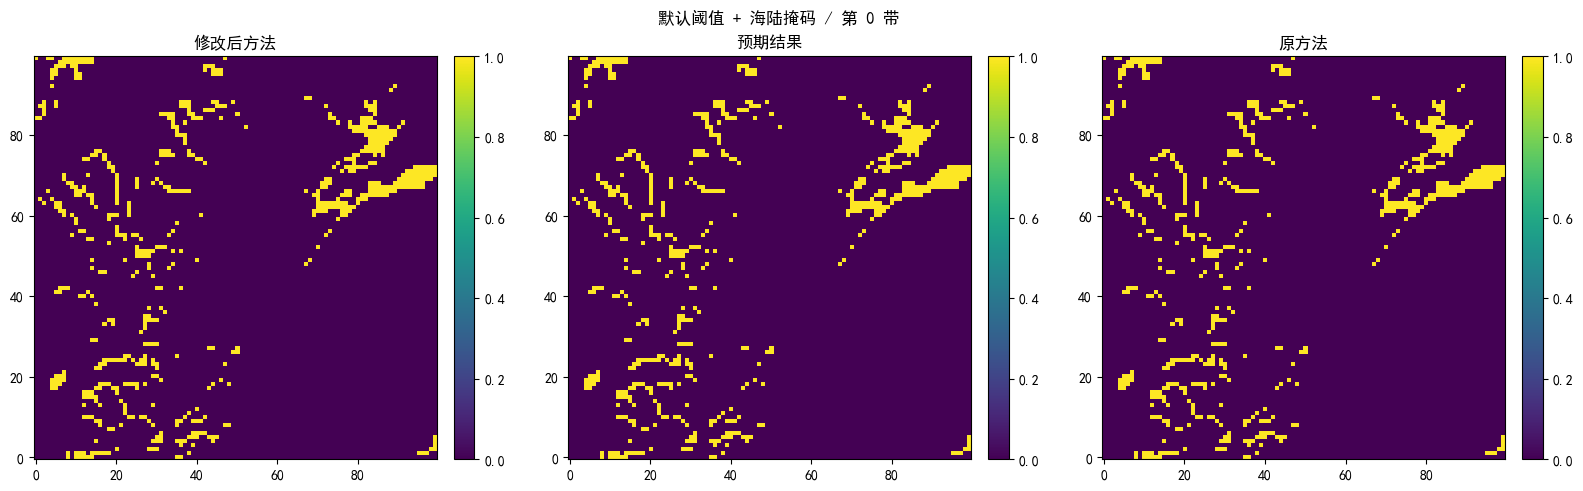

[默认阈值 + 海陆掩码 修改后方法 vs KGO] 最大绝对误差=0.00000000（接近 0 表示一致）
[默认阈值 + 海陆掩码 修改后方法 vs 原方法] 最大绝对误差=0.00000000（接近 0 表示一致）


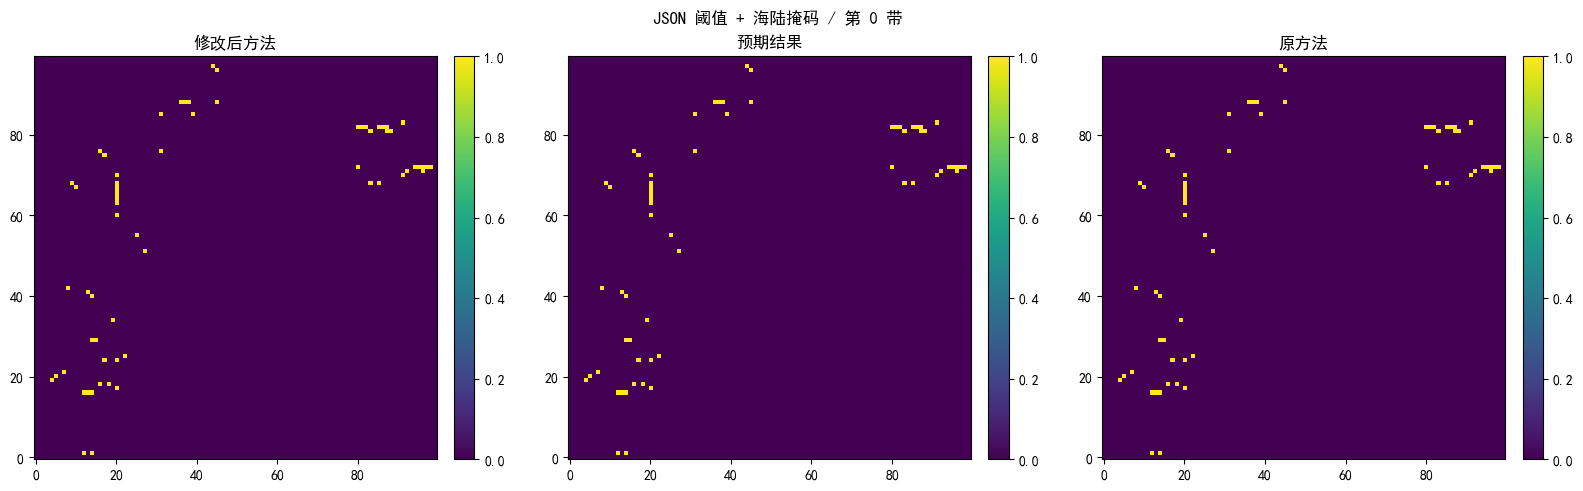

[JSON 阈值 + 海陆掩码 修改后方法 vs KGO] 最大绝对误差=0.00000000（接近 0 表示一致）
[JSON 阈值 + 海陆掩码 修改后方法 vs 原方法] 最大绝对误差=0.00000000（接近 0 表示一致）


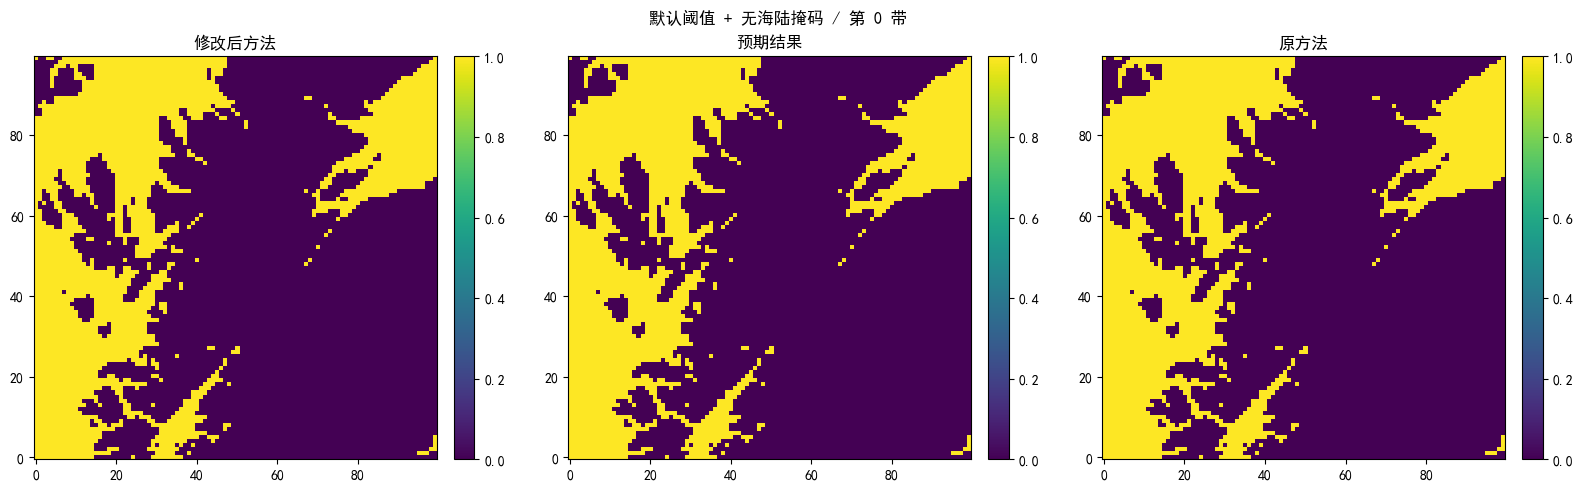

[默认阈值 + 无海陆掩码 修改后方法 vs KGO] 最大绝对误差=0.00000000（接近 0 表示一致）
[默认阈值 + 无海陆掩码 修改后方法 vs 原方法] 最大绝对误差=0.00000000（接近 0 表示一致）


In [10]:
# 三种场景都取第 0 带做对比图
cases = [
    ("默认阈值 + 海陆掩码", result_basic, kgo_basic, original_basic),
    ("JSON 阈值 + 海陆掩码", result_json, kgo_json, original_json),
    ("默认阈值 + 无海陆掩码", result_no_landmask, kgo_no_landmask, original_no_landmask),
]
for title, result, kgo, original in cases:
    modified_2d = first_band_2d(result)
    kgo_2d_band = first_band_2d(kgo)
    original_2d_band = first_band_2d(original)
    plot_result_triplet(
        f"{title} / 第 0 带",
        modified_2d,
        kgo_2d_band,
        original_2d_band,
    )
    print_max_abs(modified_2d, kgo_2d_band, f"{title} 修改后方法 vs KGO")
    print_max_abs(modified_2d, original_2d_band, f"{title} 修改后方法 vs 原方法")


### 3.3 GenerateTopographicZoneWeights

官方样例：`test_data/generate-topography-bands-weights`。

- `basic`：默认阈值 + 海陆掩码；另有 JSON 阈值 KGO
- `basic_no_landsea_mask`：无海陆掩码（输入复用 `basic`）
- `multi_realization`：多成员输入取 `member/realization=0`（与 KGO 一致；迁移版要求 member 长度为 1）


#### 辅助数据画图


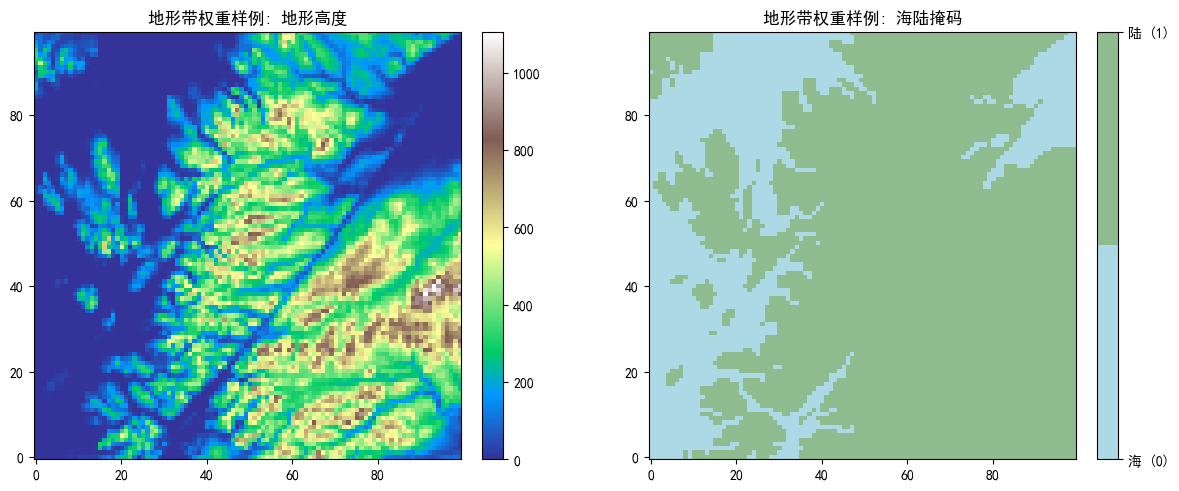

band_index | center | lower | upper
         0 | -225.0 | -500.0 |   50.0
         1 |   75.0 |   50.0 |  100.0
         2 |  125.0 |  100.0 |  150.0
         3 |  175.0 |  150.0 |  200.0
         4 |  225.0 |  200.0 |  250.0
         5 |  275.0 |  250.0 |  300.0
         6 |  350.0 |  300.0 |  400.0
         7 |  450.0 |  400.0 |  500.0
         8 |  575.0 |  500.0 |  650.0
         9 |  725.0 |  650.0 |  800.0
        10 |  875.0 |  800.0 |  950.0
        11 | 3475.0 |  950.0 | 6000.0


In [11]:
w_orog_path = W_CLI_INPUT / "input_orog_meb.nc"
w_land_path = W_CLI_INPUT / "input_land_meb.nc"
require_files([w_orog_path, w_land_path], "地形带权重投影 meb 输入")

w_orography = meb.read_griddata_from_nc(str(w_orog_path))
w_landmask = meb.read_griddata_from_nc(str(w_land_path))
with open(WEIGHTS_BASIC / "bounds.json", encoding="utf-8") as f:
    w_json_thresholds = json.load(f)

plot_auxiliary_data("地形带权重样例", w_orography, w_landmask)
print(describe_bands(THRESHOLDS_DICT))


#### 算法调用与数值对比


In [12]:
# ---------------------------------------------------------------------------
# 投影路径数值对照：同一套地形网格，按场景分别跑「迁移版 / 原方法 / KGO」
# 前面单元已读入 meb：w_orography、w_landmask、w_json_thresholds（来自 bounds.json）
# ---------------------------------------------------------------------------
w_plugin = GenerateTopographicZoneWeights()
w_orig_plugin = OrigWeightsPlugin()

# 原 Iris 官方样例（basic 目录）：供场景 1–3 的原方法调用
w_orog_cube = iris.load_cube(str(WEIGHTS_BASIC / "input_orog.nc"))
w_land_cube = iris.load_cube(str(WEIGHTS_BASIC / "input_land.nc"))

# ---- 场景 1 basic：默认 THRESHOLDS_DICT + 海陆掩码 ----
# 迁移：meb 六维；原方法：Iris Cube；KGO：WEIGHTS_BASIC/kgo.nc
w_result_basic = w_plugin(w_orography, THRESHOLDS_DICT, landmask=w_landmask)
w_original_basic = w_orig_plugin(
    w_orog_cube.copy(), THRESHOLDS_DICT, landmask=w_land_cube.copy()
)
w_kgo_basic = iris.load_cube(str(WEIGHTS_BASIC / "kgo.nc"))

# ---- 场景 2 json：自定义 bounds.json 分带 + 海陆掩码 ----
# 迁移 / 原方法共用 w_json_thresholds；KGO：kgo_from_json_bounds.nc
w_result_json = w_plugin(w_orography, w_json_thresholds, landmask=w_landmask)
w_original_json = w_orig_plugin(
    w_orog_cube.copy(), w_json_thresholds, landmask=w_land_cube.copy()
)
w_kgo_json = iris.load_cube(str(WEIGHTS_BASIC / "kgo_from_json_bounds.nc"))

# ---- 场景 3 no_landmask：默认分带，不传入海陆掩码（陆海均生成权重）----
# 迁移 / 原方法均 landmask=None；KGO 在 basic_no_landsea_mask/kgo.nc
w_result_no_landmask = w_plugin(w_orography, THRESHOLDS_DICT, landmask=None)
w_original_no_landmask = w_orig_plugin(
    w_orog_cube.copy(), THRESHOLDS_DICT, landmask=None
)
w_kgo_no_landmask = iris.load_cube(str(WEIGHTS_NO_LANDMASK / "kgo.nc"))

# ---- 场景 4 multi_r0：多成员样例，双方均只取 realization/member=0 ----
# 官方 KGO 也只对应第一成员；迁移插件要求 member 长度为 1，故先 ensure_single_member
w_multi_orog = ensure_single_member(
    meb.read_griddata_from_nc(str(WEIGHTS_MULTI / "cli_inputs" / "input_orog_meb.nc"))
)
w_multi_land = ensure_single_member(
    meb.read_griddata_from_nc(str(WEIGHTS_MULTI / "cli_inputs" / "input_land_meb.nc"))
)
w_result_multi = w_plugin(w_multi_orog, THRESHOLDS_DICT, landmask=w_multi_land)
# 原方法：从含 realization 维的 Cube 中 extract(realization=0) 得到二维场
w_orog_multi_cube = iris.load_cube(str(WEIGHTS_MULTI / "input_orog.nc")).extract(
    iris.Constraint(realization=0)
)
w_land_multi_cube = iris.load_cube(str(WEIGHTS_MULTI / "input_land.nc")).extract(
    iris.Constraint(realization=0)
)
w_original_multi = w_orig_plugin(  # 原方法调用
    w_orog_multi_cube.copy(), THRESHOLDS_DICT, landmask=w_land_multi_cube.copy()
)
w_kgo_multi = iris.load_cube(str(WEIGHTS_MULTI / "kgo.nc"))

# 四场景统一数值对比（weights_band_stack：压成 (n_band, y, x)）
for tag, cur, orig, kgo in [
    ("basic", w_result_basic, w_original_basic, w_kgo_basic),
    ("json", w_result_json, w_original_json, w_kgo_json),
    ("no_landmask", w_result_no_landmask, w_original_no_landmask, w_kgo_no_landmask),
    ("multi_r0", w_result_multi, w_original_multi, w_kgo_multi),
]:
    a = weights_band_stack(cur)
    b = weights_band_stack(orig)
    c = weights_band_stack(kgo)
    print(tag, "shapes:", a.shape, b.shape, c.shape)
    print_max_abs(a, b, f"权重投影 {tag} 修改后 vs 原方法")
    print_max_abs(a, c, f"权重投影 {tag} 修改后 vs KGO")
    np.testing.assert_allclose(a, b, equal_nan=True, atol=1e-5, rtol=1e-5)
    np.testing.assert_allclose(a, c, equal_nan=True, atol=1e-5, rtol=1e-5)

print("GenerateTopographicZoneWeights 投影路径：与原方法 / KGO 一致。")


basic shapes: (12, 100, 100) (12, 100, 100) (12, 100, 100)
[权重投影 basic 修改后 vs 原方法] 最大绝对误差=0.00000000（接近 0 表示一致）
[权重投影 basic 修改后 vs KGO] 最大绝对误差=0.00000000（接近 0 表示一致）
json shapes: (6, 100, 100) (6, 100, 100) (6, 100, 100)
[权重投影 json 修改后 vs 原方法] 最大绝对误差=0.00000000（接近 0 表示一致）
[权重投影 json 修改后 vs KGO] 最大绝对误差=0.00000000（接近 0 表示一致）
no_landmask shapes: (12, 100, 100) (12, 100, 100) (12, 100, 100)
[权重投影 no_landmask 修改后 vs 原方法] 最大绝对误差=0.00000000（接近 0 表示一致）
[权重投影 no_landmask 修改后 vs KGO] 最大绝对误差=0.00000000（接近 0 表示一致）
multi_r0 shapes: (12, 100, 100) (12, 100, 100) (12, 100, 100)
[权重投影 multi_r0 修改后 vs 原方法] 最大绝对误差=0.00000000（接近 0 表示一致）
[权重投影 multi_r0 修改后 vs KGO] 最大绝对误差=0.00000000（接近 0 表示一致）
GenerateTopographicZoneWeights 投影路径：与原方法 / KGO 一致。


#### 结果对比画图


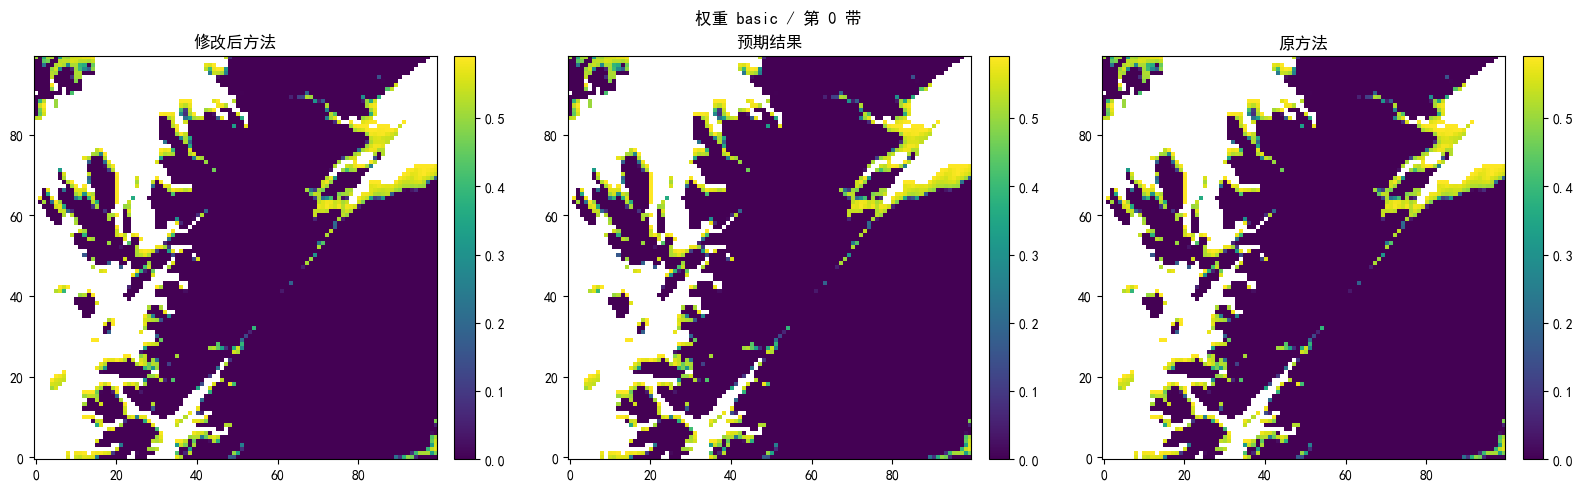

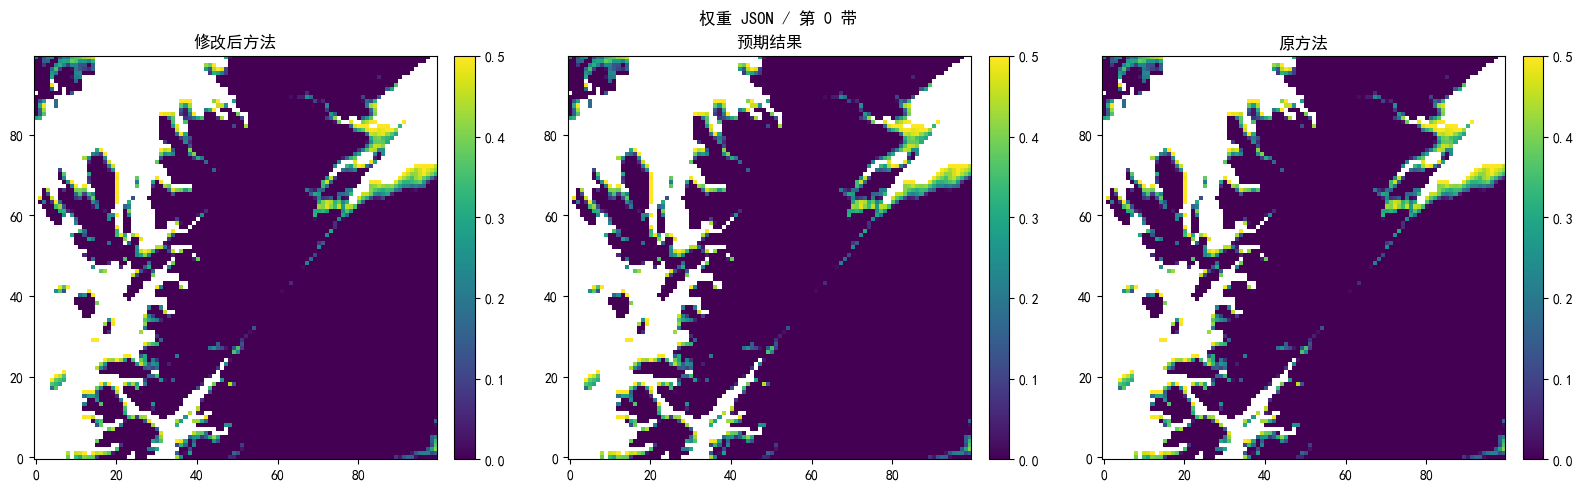

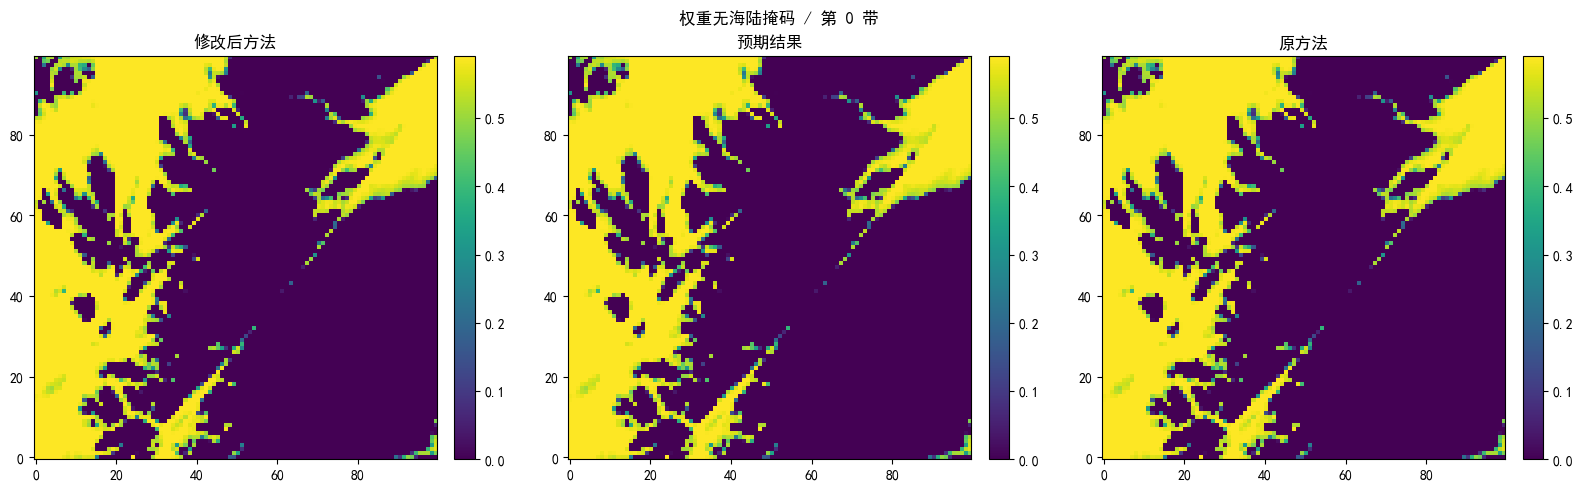

In [13]:
# 三种场景：取第 0 带画对比图
for title, cur, kgo, orig in [
    ("权重 basic / 第 0 带", w_result_basic, w_kgo_basic, w_original_basic),
    ("权重 JSON / 第 0 带", w_result_json, w_kgo_json, w_original_json),
    ("权重无海陆掩码 / 第 0 带", w_result_no_landmask, w_kgo_no_landmask, w_original_no_landmask),
]:
    plot_result_triplet(
        title,
        weights_band_stack(cur)[0],
        weights_band_stack(kgo)[0],
        weights_band_stack(orig)[0],
    )


## 4. 经纬坐标输入

读取预处理写出的 `latlon/` Cube 与 `latlon/cli_inputs/` meb。
经纬网格和投影网格的格距不同，**不要拿投影 KGO 来比**；这里的主判据是同一经纬输入下「修改后方法 vs 原方法」。


### 4.1 CorrectLandSeaMask


#### 算法运行与数值对比

调用方式与投影路径相同，只是输入换成了经纬网格。


In [14]:
ll_land_cube_path = LANDMASK_BASIC / "latlon" / "input.nc"
ll_land_meb_path = LANDMASK_BASIC / "latlon" / "cli_inputs" / "input_landmask_meb.nc"
require_files([ll_land_cube_path, ll_land_meb_path], "海陆掩码经纬输入")

land_frac_ll = meb.read_griddata_from_nc(str(ll_land_meb_path))
land_latlon_cube = iris.load_cube(str(ll_land_cube_path))
print("latlon input:", land_frac_ll.shape, "lat attrs=", dict(land_frac_ll.coords["lat"].attrs))

# 修改后插件调用
cur_ll = CorrectLandSeaMask().process(land_frac_ll)
# 原方法调用
orig_ll_cube = OrigCorrectLandSeaMask()(land_latlon_cube)
cur_ll_2d = to_2d(cur_ll)
orig_ll_2d = to_2d(orig_ll_cube)
print_max_abs(cur_ll_2d, orig_ll_2d, "经纬 修改后方法 vs 原方法")
np.testing.assert_array_equal(cur_ll_2d, orig_ll_2d)
print("CorrectLandSeaMask 经纬路径：与原方法一致。")


latlon input: (1, 1, 1, 1, 346, 792) lat attrs= {}
[经纬 修改后方法 vs 原方法] 最大绝对误差=0.00000000（接近 0 表示一致）
CorrectLandSeaMask 经纬路径：与原方法一致。


#### 输出对比绘图


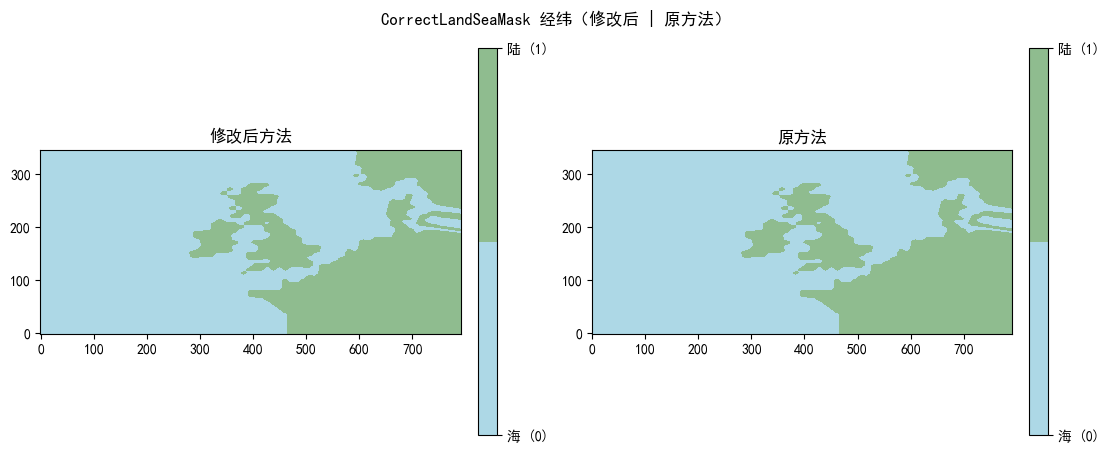

In [15]:
plot_landmask_pair_or_triplet(
    "CorrectLandSeaMask 经纬（修改后 | 原方法）",
    cur_ll_2d,
    orig_ll_2d,
)


### 4.2 GenerateOrographyBandAncils

主判据仍是同一经纬输入下「修改后方法 vs 原方法」。这里只演示默认阈值 + 海陆掩码。


#### 算法运行与数值对比


In [16]:
ll_orog_cube_path = BASIC_DIR / "latlon" / "input_orog.nc"
ll_land_cube_path = BASIC_DIR / "latlon" / "input_land.nc"
ll_orog_meb_path = BASIC_DIR / "latlon" / "cli_inputs" / "input_orog_meb.nc"
ll_land_meb_path = BASIC_DIR / "latlon" / "cli_inputs" / "input_land_meb.nc"
require_files(
    [ll_orog_cube_path, ll_land_cube_path, ll_orog_meb_path, ll_land_meb_path],
    "地形带经纬输入",
)

orog_ll = meb.read_griddata_from_nc(str(ll_orog_meb_path))
land_ll = meb.read_griddata_from_nc(str(ll_land_meb_path))
orog_ll_cube = iris.load_cube(str(ll_orog_cube_path))
land_ll_cube = iris.load_cube(str(ll_land_cube_path))

# 修改后方法调用
cur_bands_ll = GenerateOrographyBandAncils().process(
    orog_ll, THRESHOLDS_DICT, landmask=land_ll
)
# 原方法返回 CubeList，取第 0 带与迁移结果的 level=0 对齐
orig_bands_ll = OrigBandsPlugin()(
    orog_ll_cube, THRESHOLDS_DICT, landmask=land_ll_cube
)

cur0 = first_band_2d(cur_bands_ll)
orig0 = to_2d(np.asarray(orig_bands_ll[0].data)).astype(float)
print("bands latlon shapes:", cur0.shape, orig0.shape)
print_max_abs(cur0, orig0, "经纬第 0 带 修改后方法 vs 原方法")
np.testing.assert_array_equal(cur0, orig0)
print("GenerateOrographyBandAncils 经纬路径：与原方法一致。")


bands latlon shapes: (38, 69) (38, 69)
[经纬第 0 带 修改后方法 vs 原方法] 最大绝对误差=0.00000000（接近 0 表示一致）
GenerateOrographyBandAncils 经纬路径：与原方法一致。


#### 输出对比绘图

经纬路径没有对应的投影 KGO，所以只画两列，不再把原方法重复画一遍冒充第三列。


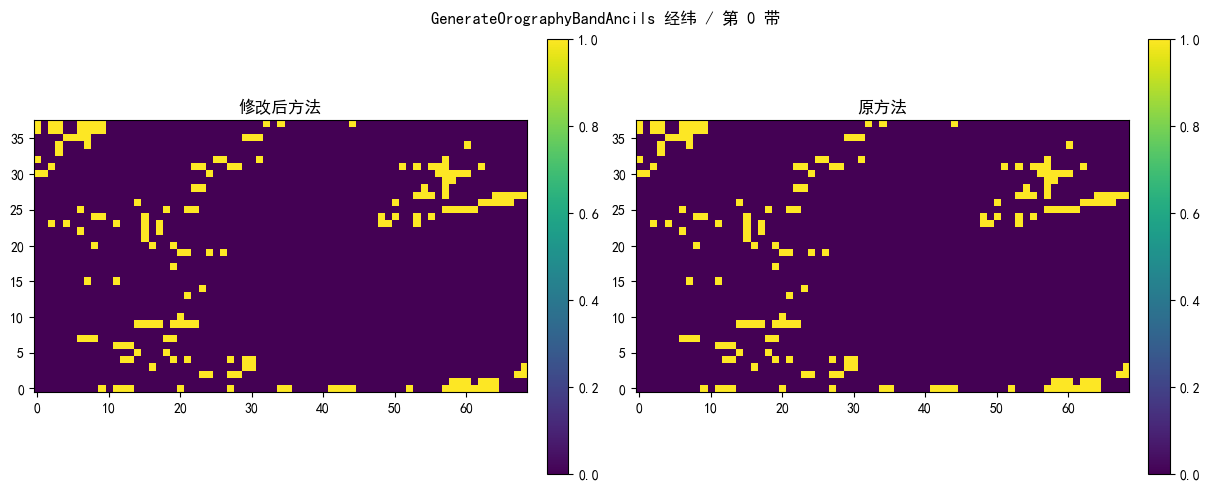

In [17]:
plot_pair(
    "GenerateOrographyBandAncils 经纬 / 第 0 带",
    cur0,
    orig0,
)


### 4.3 GenerateTopographicZoneWeights

读取预处理写出的 `latlon/` Cube 与 `latlon/cli_inputs/` meb；对照迁移版与原方法（无投影 KGO）。


#### 算法调用与数值对比


In [18]:
ll_w_orog_cube_path = WEIGHTS_BASIC / "latlon" / "input_orog.nc"
ll_w_land_cube_path = WEIGHTS_BASIC / "latlon" / "input_land.nc"
ll_w_orog_meb_path = WEIGHTS_BASIC / "latlon" / "cli_inputs" / "input_orog_meb.nc"
ll_w_land_meb_path = WEIGHTS_BASIC / "latlon" / "cli_inputs" / "input_land_meb.nc"
require_files(
    [ll_w_orog_cube_path, ll_w_land_cube_path, ll_w_orog_meb_path, ll_w_land_meb_path],
    "地形带权重经纬输入",
)

w_orog_ll = meb.read_griddata_from_nc(str(ll_w_orog_meb_path))
w_land_ll = meb.read_griddata_from_nc(str(ll_w_land_meb_path))
w_orog_ll_cube = iris.load_cube(str(ll_w_orog_cube_path))
w_land_ll_cube = iris.load_cube(str(ll_w_land_cube_path))

# 修改后插件方法调用
cur_w_ll = GenerateTopographicZoneWeights().process(
    w_orog_ll, THRESHOLDS_DICT, landmask=w_land_ll
)
# 原插件方法调用
orig_w_ll = OrigWeightsPlugin()(
    w_orog_ll_cube, THRESHOLDS_DICT, landmask=w_land_ll_cube
)

a = weights_band_stack(cur_w_ll)
b = weights_band_stack(orig_w_ll)
print("weights latlon shapes:", a.shape, b.shape)
print_max_abs(a, b, "经纬权重 修改后 vs 原方法")
np.testing.assert_allclose(a, b, equal_nan=True, atol=1e-5, rtol=1e-5)
print("GenerateTopographicZoneWeights 经纬路径：与原方法一致。")


weights latlon shapes: (12, 38, 69) (12, 38, 69)
[经纬权重 修改后 vs 原方法] 最大绝对误差=0.00000000（接近 0 表示一致）
GenerateTopographicZoneWeights 经纬路径：与原方法一致。


#### 结果对比画图


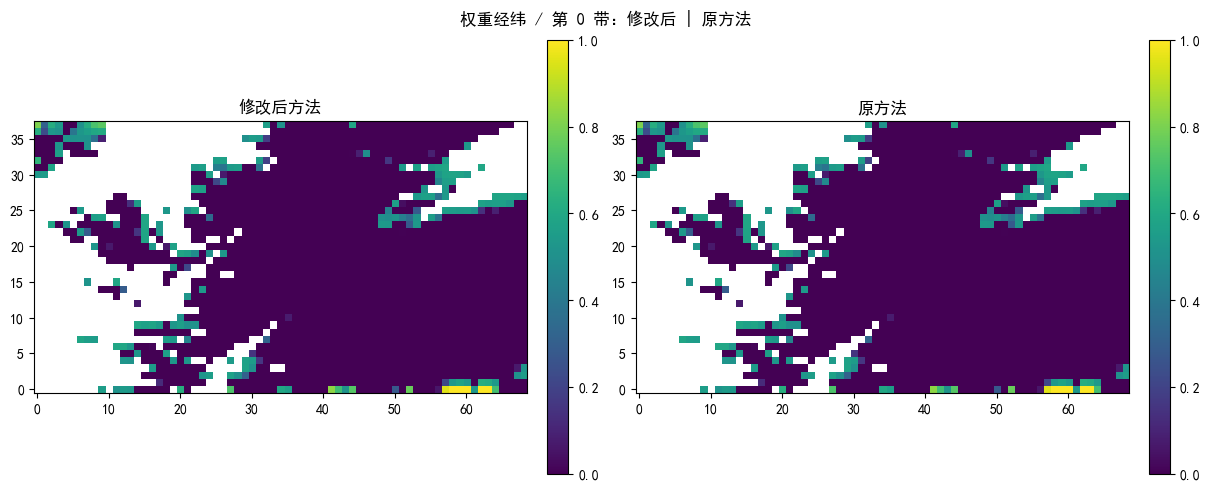

In [19]:
plot_pair(
    "权重经纬 / 第 0 带：修改后 | 原方法",
    weights_band_stack(cur_w_ll)[0],
    weights_band_stack(orig_w_ll)[0],
)


## 5. CLI 示例

CLI 脚本的入口函数 `process()` 接收的是 **nc 文件路径**（不是已经读好的数组）。
脚本内部会自己读盘、调用算法，并把结果写到与脚本底部相同的 `cli_outputs/` 文件。

下面用投影坐标的 `cli_inputs/` 演示调用，并与 KGO / 原 CLI 结果对照。终端里也可以直接跑（先改脚本底部的路径）：

```text
python generate_ancillary/cli/anc_generate_landmask_ancillary.py
python generate_ancillary/cli/dsc_generate_topography_bands_mask.py
python generate_ancillary/cli/dsc_generate_topographic_zone_weights.py
```


### 5.1 CorrectLandSeaMask

对比三路：修改后 CLI | 原方法 CLI | KGO。写出文件名与脚本底部一致。


CLI wrote: D:\workspace\improver\generate_ancillary\test_data\generate-landmask\basic\cli_outputs\cli_landmask_result.nc shape= (1, 1, 1, 1, 49, 53)
[修改后 CLI vs KGO] 最大绝对误差=0.00000000（接近 0 表示一致）
[修改后 CLI vs 原方法 CLI] 最大绝对误差=0.00000000（接近 0 表示一致）
[原方法 CLI vs KGO] 最大绝对误差=0.00000000（接近 0 表示一致）
CorrectLandSeaMask：修改后 CLI / 原方法 CLI 均与 KGO 一致。


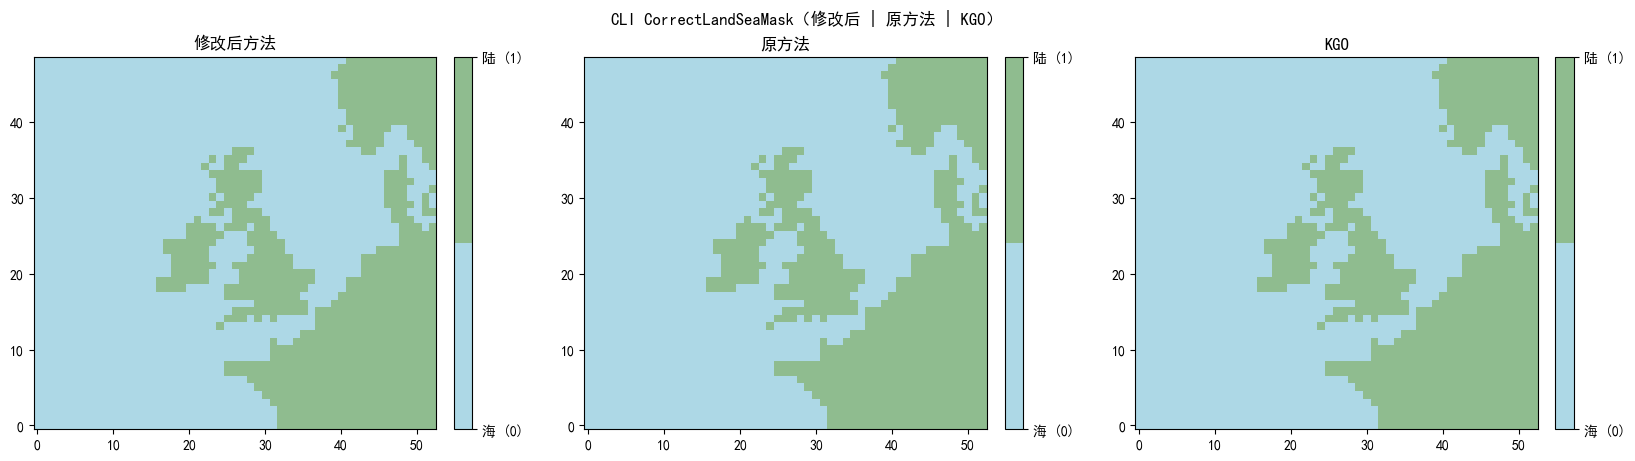

In [20]:
from generate_ancillary.cli.anc_generate_landmask_ancillary import process as landmask_cli_process

LM_CLI_OUTPUT.mkdir(parents=True, exist_ok=True)
lm_out = LM_CLI_OUTPUT / "cli_landmask_result.nc"

# 修改后方法的cli调用
cli_lm = landmask_cli_process(
    landmask_path=str(LM_CLI_INPUT / "input_landmask_meb.nc"),
    output_path=str(lm_out),
)
cli_lm_2d = to_2d(cli_lm).astype(np.float64)

# 原 IMPROVER CLI 事先写出的对照文件
orig_cli_lm = iris.load_cube(str(LM_CLI_OUTPUT / "original_cli_landmask_result.nc"))
orig_cli_2d = to_2d(orig_cli_lm).astype(np.float64)

print("CLI wrote:", lm_out, "shape=", cli_lm.shape)
print_max_abs(cli_lm_2d, kgo_2d, "修改后 CLI vs KGO")
print_max_abs(cli_lm_2d, orig_cli_2d, "修改后 CLI vs 原方法 CLI")
print_max_abs(orig_cli_2d, kgo_2d, "原方法 CLI vs KGO")
np.testing.assert_array_equal(cli_lm_2d, kgo_2d)
np.testing.assert_array_equal(orig_cli_2d, kgo_2d)
print("CorrectLandSeaMask：修改后 CLI / 原方法 CLI 均与 KGO 一致。")

plot_landmask_pair_or_triplet(
    "CLI CorrectLandSeaMask（修改后 | 原方法 | KGO）",
    cli_lm_2d,
    orig_cli_2d,
    kgo=kgo_2d,
)


### 5.2 GenerateOrographyBandAncils

调用 `dsc_generate_topography_bands_mask.process`（JSON 阈值场景），对比修改后 CLI / 原方法 CLI / KGO。


shape(cli): (5, 100, 100) shape(orig_cli): (5, 100, 100) shape(kgo): (5, 100, 100)
[修改后 CLI vs KGO] 最大绝对误差=0.00000000（接近 0 表示一致）
[修改后 CLI vs 原方法 CLI] 最大绝对误差=0.00000000（接近 0 表示一致）
[原方法 CLI vs KGO] 最大绝对误差=0.00000000（接近 0 表示一致）


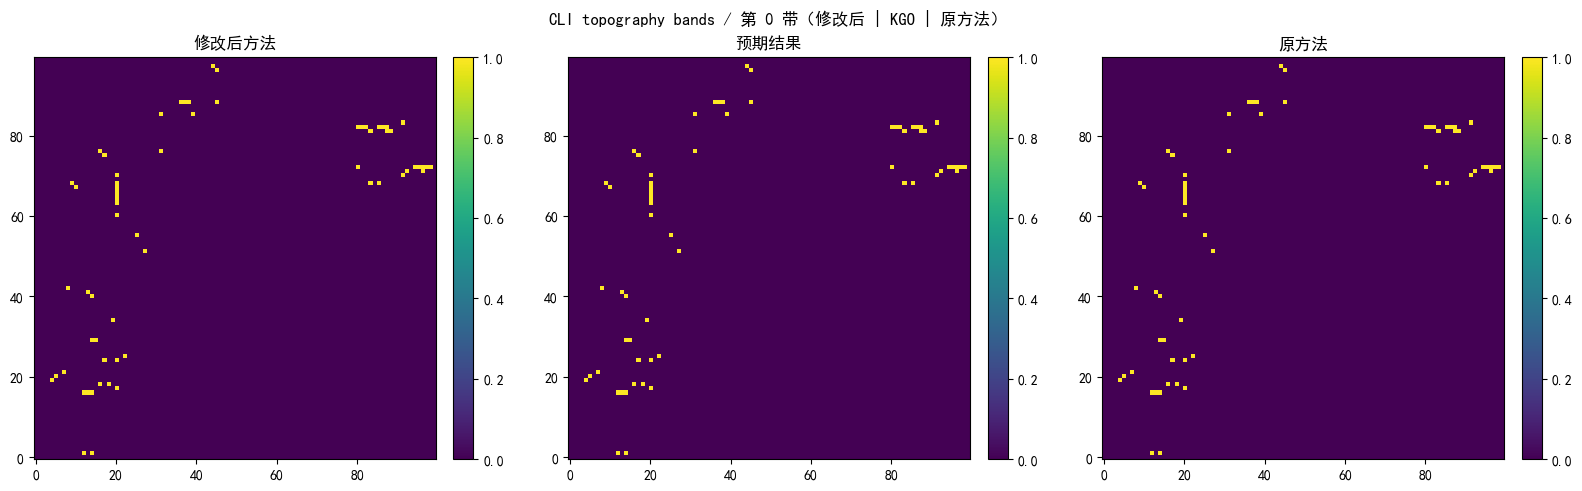

In [21]:
from generate_ancillary.cli.dsc_generate_topography_bands_mask import process as bands_cli_process

CLI_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
cli_result_path = CLI_OUTPUT_DIR / "cli_topography_bands_mask_result.nc"

# 修改后方法的cli调用
cli_result = bands_cli_process(
    orography_path=str(CLI_INPUT_DIR / "input_orog_meb.nc"),
    landmask_path=str(CLI_INPUT_DIR / "input_land_meb.nc"),
    thresholds_path=str(BASIC_DIR / "bounds.json"),
    output_path=str(cli_result_path),
)

cli_result_2d = np.asarray(cli_result.squeeze(drop=True).values)
kgo_cube = np.asarray(kgo_json.data, dtype=np.float64)

# 原 IMPROVER CLI 事先写出的对照文件
orig_cli_bands = iris.load_cube(str(CLI_OUTPUT_DIR / "original_cli_topography_bands_mask_result.nc"))
orig_cli_cube = np.asarray(orig_cli_bands.data, dtype=np.float64)

print("shape(cli):", cli_result_2d.shape, "shape(orig_cli):", orig_cli_cube.shape, "shape(kgo):", kgo_cube.shape)
print_max_abs(cli_result_2d, kgo_cube, "修改后 CLI vs KGO")
print_max_abs(cli_result_2d, orig_cli_cube, "修改后 CLI vs 原方法 CLI")
print_max_abs(orig_cli_cube, kgo_cube, "原方法 CLI vs KGO")

plot_result_triplet(
    "CLI topography bands / 第 0 带（修改后 | KGO | 原方法）",
    cli_result_2d[0],
    kgo_cube[0],
    orig_cli_cube[0],
)


### 5.3 GenerateTopographicZoneWeights

调用 `dsc_generate_topographic_zone_weights.process`（JSON 阈值），三方对比修改后 CLI / 原方法 CLI / KGO。


[修改后 CLI vs KGO] 最大绝对误差=0.00000000（接近 0 表示一致）
[修改后 CLI vs 原方法 CLI] 最大绝对误差=0.00000000（接近 0 表示一致）
[原方法 CLI vs KGO] 最大绝对误差=0.00000000（接近 0 表示一致）


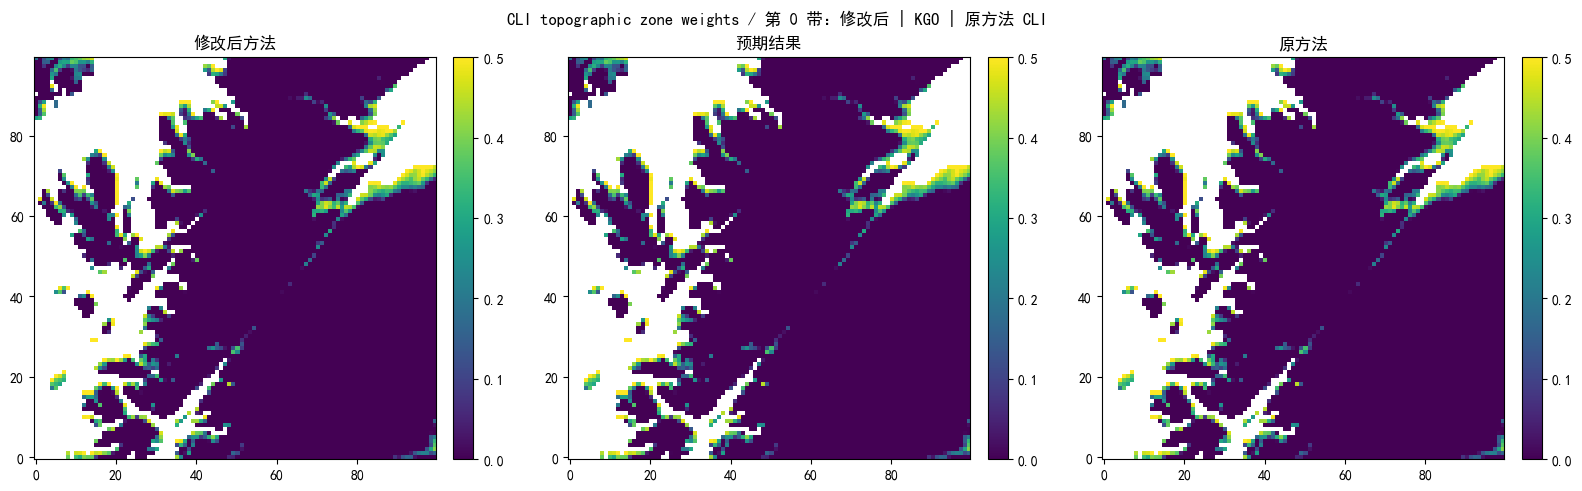

In [22]:
from generate_ancillary.cli.dsc_generate_topographic_zone_weights import (
    process as weights_cli_process,
)

W_CLI_OUTPUT.mkdir(parents=True, exist_ok=True)
w_cli_result_path = W_CLI_OUTPUT / "cli_topographic_zone_weights_result.nc"

# 修改后方法：cli运行
w_cli_result = weights_cli_process(
    orography_path=str(W_CLI_INPUT / "input_orog_meb.nc"),
    landmask_path=str(W_CLI_INPUT / "input_land_meb.nc"),
    thresholds_path=str(WEIGHTS_BASIC / "bounds.json"),
    output_path=str(w_cli_result_path),
)

w_cli_stack = weights_band_stack(w_cli_result)
w_kgo_json_stack = weights_band_stack(w_kgo_json)

# 原 IMPROVER CLI 结果
orig_cli_weights = iris.load_cube(
    str(W_CLI_OUTPUT / "original_cli_topographic_zone_weights_result.nc")
)
orig_cli_stack = weights_band_stack(orig_cli_weights)

print_max_abs(w_cli_stack, w_kgo_json_stack, "修改后 CLI vs KGO")
print_max_abs(w_cli_stack, orig_cli_stack, "修改后 CLI vs 原方法 CLI")
print_max_abs(orig_cli_stack, w_kgo_json_stack, "原方法 CLI vs KGO")
np.testing.assert_allclose(
    w_cli_stack, w_kgo_json_stack, equal_nan=True, atol=1e-5, rtol=1e-5
)
np.testing.assert_allclose(
    w_cli_stack, orig_cli_stack, equal_nan=True, atol=1e-5, rtol=1e-5
)

plot_result_triplet(
    "CLI topographic zone weights / 第 0 带：修改后 | KGO | 原方法 CLI",
    w_cli_stack[0],
    w_kgo_json_stack[0],
    orig_cli_stack[0],
)
